<h2><b>Statistical Arbitrage in the Crypto Asset Class Using Cointegrated Altcoin Baskets</b></h2>

**Core Intuition** : The idea is to find large-cap altcoins that historically move together. When their prices temporarily diverge from this relationship, we take a market-neutral position and profit when the prices revert back to their normal relationship.

In [1]:
from binance.client import Client
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from datetime import datetime
from tqdm import tqdm
import networkx as nx
import json

import warnings
warnings.filterwarnings('ignore')

In [2]:
import mlflow
import os

mlflow.set_tracking_uri(f"file://{os.path.abspath('mlruns')}")
mlflow.set_experiment("crypto-stat-arb")

2026/03/10 21:31:42 INFO mlflow.tracking.fluent: Experiment with name 'crypto-stat-arb' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///Users/sujith/Desktop/Files/Quant/capstone_project/mlruns/872495591171778896', creation_time=1773203502451, experiment_id='872495591171778896', last_update_time=1773203502451, lifecycle_stage='active', name='crypto-stat-arb', tags={}, workspace='default'>

In [3]:
if mlflow.active_run():
    mlflow.end_run()

mlflow.start_run(run_name="v1")

<ActiveRun: >

### **Data Acquisition: Historical Cryptocurrency Prices from Binance**

In [4]:
class BinanceDataLoader:

    def __init__(self):

        # public API works fine for historical klines
        self.client = Client(tld='US')

    def get_klines(self, symbol, interval, start, end):

        klines = self.client.get_historical_klines(
            symbol,
            interval,
            start,
            end
        )

        df = pd.DataFrame(klines, columns=[
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "close_time",
            "quote_asset_volume",
            "number_of_trades",
            "taker_buy_base",
            "taker_buy_quote",
            "ignore"
        ])

        df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")

        df = df.set_index("open_time")

        df = df.astype(float)

        return df

    def download_prices(self, symbols, interval="1d", start="1 Jan 2021", end = "1 Mar 2026"):

        prices = {}

        for symbol in tqdm(symbols):

            try:

                df = self.get_klines(symbol, interval, start, end)

                prices[symbol] = df["close"]

            except Exception as e:

                print(f"Failed: {symbol}")

        prices = pd.DataFrame(prices)

        prices = prices.sort_index()

        return prices

In [5]:
symbols = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "SOLUSDT",
    "AVAXUSDT",
    "NEARUSDT",
    "ADAUSDT",
    "LINKUSDT",
    "UNIUSDT",
    "AAVEUSDT",
    "MATICUSDT",
    "ATOMUSDT",
    "DOTUSDT",
    "FTMUSDT",
    "FILUSDT"
]

loader = BinanceDataLoader()

prices = loader.download_prices(
    symbols,
    interval="1d",
    start="1 Jan 2021",
    end= '1 Mar 2026'
)

100%|██████████| 15/15 [00:06<00:00,  2.46it/s]


In [6]:
mlflow.log_param("symbols", symbols)
mlflow.log_param("interval", "1d")
mlflow.log_param("start_date", "2021-01-01")
mlflow.log_param("end_date","2026-03-01")

mlflow.log_metric("num_assets", prices.shape[1])
mlflow.log_metric("num_observations", prices.shape[0])

In [7]:
prices = prices.ffill()

TRAIN_END = "2025-06-30"
TEST_START = "2025-07-01"

prices_train = prices.loc[:TRAIN_END]
prices_test = prices.loc[TEST_START:]

In [8]:
mlflow.log_param("train_end", TRAIN_END)
mlflow.log_param("test_start", TEST_START)

'2025-07-01'

In [9]:
prices_train

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,AVAXUSDT,NEARUSDT,ADAUSDT,LINKUSDT,UNIUSDT,AAVEUSDT,MATICUSDT,ATOMUSDT,DOTUSDT,FTMUSDT,FILUSDT
open_time,,,,,,,,,,,,,,,
2021-01-01,29305.29,728.52,37.6696,1.8455,NaN,NaN,0.17488,NaN,4.7488,NaN,NaN,5.865,NaN,NaN,NaN
2021-01-02,32162.01,774.56,38.2207,1.7955,NaN,NaN,0.17726,NaN,4.8595,NaN,NaN,5.404,NaN,NaN,NaN
2021-01-03,33031.74,978.14,41.1282,2.1682,NaN,NaN,0.20624,NaN,5.5152,NaN,NaN,5.826,NaN,NaN,NaN
2021-01-04,32005.27,1042.10,41.0884,2.4924,NaN,NaN,0.22533,NaN,5.4310,NaN,NaN,6.045,NaN,NaN,NaN
2021-01-05,33946.09,1100.22,41.8000,2.1561,NaN,NaN,0.25913,NaN,6.2500,NaN,NaN,6.192,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,107013.01,2414.91,642.0200,138.9100,17.22,2.048,0.55400,12.95,6.7850,249.37,0.4492,3.893,3.305,0.4806,2.209
2025-06-27,107000.01,2421.92,646.1700,142.2000,17.61,2.116,0.55880,13.04,6.9590,258.62,0.4492,3.938,3.361,0.4806,2.226
2025-06-28,107325.32,2437.40,648.7200,150.7000,18.01,2.171,0.56520,13.39,7.1640,261.23,0.4492,3.994,3.406,0.4806,2.277


In [10]:
prices_test

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,AVAXUSDT,NEARUSDT,ADAUSDT,LINKUSDT,UNIUSDT,AAVEUSDT,MATICUSDT,ATOMUSDT,DOTUSDT,FTMUSDT,FILUSDT
open_time,,,,,,,,,,,,,,,
2025-07-01,105668.01,2402.84,646.37,146.92,17.11,2.040,0.5422,12.84,6.611,259.95,0.4492,3.924,3.277,0.4806,2.258
2025-07-02,108702.81,2567.25,658.86,152.15,18.50,2.213,0.5836,13.57,7.400,276.26,0.4492,4.206,3.543,0.4806,2.373
2025-07-03,109628.73,2589.38,663.63,152.66,18.50,2.277,0.5986,13.68,7.467,278.59,0.4492,4.200,3.540,0.4806,2.396
2025-07-04,107947.38,2511.30,653.55,147.49,17.84,2.127,0.5738,13.14,6.968,264.78,0.4492,3.979,3.328,0.4806,2.254
2025-07-05,108260.00,2517.60,656.19,147.52,17.92,2.157,0.5768,13.21,7.370,273.74,0.4492,3.985,3.367,0.4806,2.215
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-25,67957.93,2057.35,625.47,88.03,9.50,1.173,0.2958,9.20,4.097,118.46,0.4492,1.930,1.639,0.4806,1.091
2026-02-26,67481.40,2026.71,625.93,85.93,9.30,1.130,0.2869,9.11,3.774,116.20,0.4492,1.901,1.643,0.4806,1.033
2026-02-27,65882.98,1929.82,614.20,81.98,8.94,1.098,0.2771,8.68,3.676,111.54,0.4492,1.876,1.603,0.4806,0.975


Step 2

In [11]:
log_returns = np.log(prices_train).diff()
log_returns = log_returns.dropna()

In [12]:
log_returns

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,AVAXUSDT,NEARUSDT,ADAUSDT,LINKUSDT,UNIUSDT,AAVEUSDT,MATICUSDT,ATOMUSDT,DOTUSDT,FTMUSDT,FILUSDT
open_time,,,,,,,,,,,,,,,
2022-01-21,-0.109374,-0.156508,-0.135804,-0.127146,-0.183279,-0.143384,-0.116539,-0.156880,-0.129233,-0.149551,-0.137923,-0.120184,-0.156106,-0.168242,-0.166394
2022-01-22,-0.039213,-0.063211,-0.069253,-0.171464,-0.100633,-0.146073,-0.044017,-0.089069,-0.131395,-0.153197,-0.105100,-0.166201,-0.074225,-0.143890,-0.156561
2022-01-23,0.033421,0.051392,0.068632,0.054288,0.080467,0.026574,0.047268,0.049454,0.028779,0.073602,0.053312,0.169114,0.028019,0.146132,0.029651
2022-01-24,0.010272,-0.039206,-0.033702,-0.083601,-0.027060,-0.094627,-0.053627,-0.059005,-0.068321,-0.036714,-0.070407,0.036259,-0.045104,-0.009220,-0.054779
2022-01-25,0.008314,0.006072,0.036293,0.029642,0.074968,0.128141,-0.023149,-0.010936,-0.006384,-0.004735,0.029404,-0.007752,0.019814,0.052449,-0.014726
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,-0.001550,-0.001758,-0.004569,-0.031951,-0.013268,-0.037379,-0.022312,-0.013804,-0.023596,-0.025419,0.000000,-0.023106,-0.010834,0.000000,-0.016611
2025-06-27,-0.000121,0.002899,0.006443,0.023408,0.022395,0.032664,0.008627,0.006926,0.025321,0.036422,0.000000,0.011493,0.016802,0.000000,0.007666
2025-06-28,0.003036,0.006371,0.003939,0.058057,0.022460,0.025660,0.011388,0.026487,0.029033,0.010041,0.000000,0.014120,0.013300,0.000000,0.022653


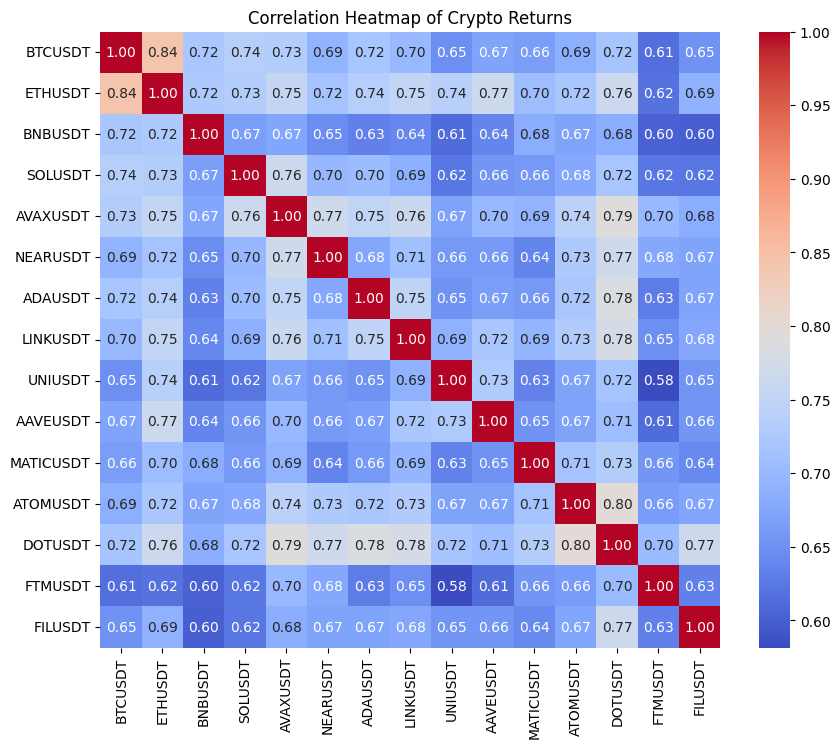

In [13]:
corr_matrix = log_returns.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Crypto Returns")
plt.show()

Remove 1st PCA component

In [14]:
from sklearn.decomposition import PCA
def remove_market_factor(returns, n_factors=1):

    pca = PCA(n_components=n_factors)
    # fit PCA
    factors = pca.fit_transform(returns)
    # reconstruct common component
    reconstructed = pca.inverse_transform(factors)

    reconstructed = pd.DataFrame(
        reconstructed,
        index=returns.index,
        columns=returns.columns
    )

    # residual returns
    residuals = returns - reconstructed

    return residuals

In [15]:
n_factors=1
residual_returns = remove_market_factor(log_returns,n_factors)
residual_returns

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,AVAXUSDT,NEARUSDT,ADAUSDT,LINKUSDT,UNIUSDT,AAVEUSDT,MATICUSDT,ATOMUSDT,DOTUSDT,FTMUSDT,FILUSDT
open_time,,,,,,,,,,,,,,,
2022-01-21,-0.027856,-0.042433,-0.052158,0.030164,-0.020994,0.030205,0.021927,-0.012568,0.021615,0.005751,-0.003893,0.021813,-0.017583,0.008164,-0.013045
2022-01-22,0.025591,0.027724,-0.002662,-0.046138,0.028929,-0.007428,0.066452,0.025996,-0.011074,-0.029493,0.001944,-0.052684,0.036470,-0.003038,-0.033971
2022-01-23,-0.004314,0.000368,0.030597,-0.016597,0.009284,-0.049147,-0.014019,-0.014901,-0.038175,0.003464,-0.005197,0.107914,-0.031995,0.068877,-0.036455
2022-01-24,0.034135,-0.004952,-0.008886,-0.036618,0.022349,-0.041573,-0.011736,-0.015578,-0.022774,0.009593,-0.029464,0.080016,-0.002569,0.044547,-0.007531
2022-01-25,-0.006271,-0.012902,0.021879,0.003054,0.049107,0.100818,-0.045658,-0.034784,-0.031058,-0.031110,0.008271,-0.029506,-0.001660,0.024435,-0.038231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,0.006478,0.010574,0.004090,-0.015268,0.005141,-0.017428,-0.006945,0.001915,-0.006969,-0.009046,0.015376,-0.006331,0.005340,0.020085,0.001498
2025-06-27,-0.009625,-0.009040,-0.002786,0.006544,0.006482,0.015963,-0.005371,-0.008031,0.009928,0.019653,-0.012929,-0.001604,0.003788,-0.017206,-0.006487
2025-06-28,-0.008236,-0.008015,-0.007094,0.037810,0.003086,0.005264,-0.005571,0.008436,0.010411,-0.010069,-0.015783,-0.001988,-0.002657,-0.020966,0.005246


In [16]:
mlflow.log_param("pca_removed_components", n_factors)

1

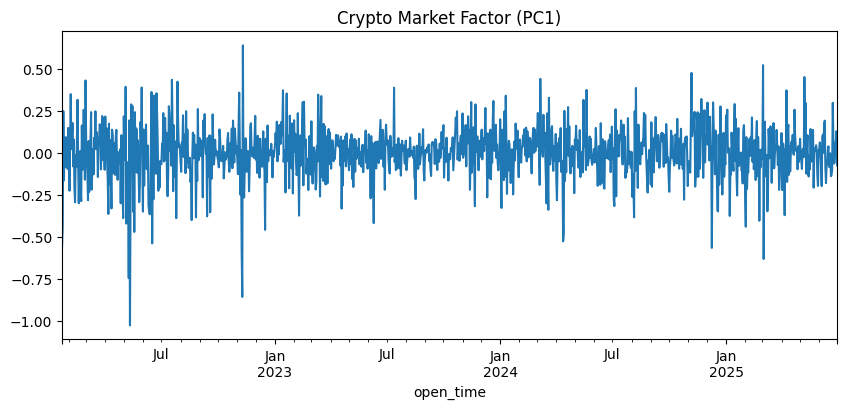

In [17]:
pca = PCA(n_components=1)
factor = pca.fit_transform(log_returns)

factor_series = pd.Series(
    factor.flatten(),
    index=log_returns.index
)

factor_series.plot(figsize=(10,4))
plt.title("Crypto Market Factor (PC1)")
plt.show()

Step-3 network build

In [18]:
from sklearn.covariance import LedoitWolf
def compute_shrinkage_covariance(returns):

    lw = LedoitWolf()

    lw.fit(returns)

    cov_matrix = lw.covariance_

    cov_matrix = pd.DataFrame(
        cov_matrix,
        index=returns.columns,
        columns=returns.columns
    )

    return cov_matrix

def covariance_to_correlation(cov_matrix):

    std = np.sqrt(np.diag(cov_matrix))

    corr = cov_matrix / np.outer(std, std)

    corr = pd.DataFrame(
        corr,
        index=cov_matrix.index,
        columns=cov_matrix.columns
    )

    return corr

cov_matrix_after_lws = compute_shrinkage_covariance(residual_returns)
corr_matrix_after_lws = covariance_to_correlation(cov_matrix_after_lws)

In [19]:
mlflow.log_param("covariance_estimator", "LedoitWolf")

'LedoitWolf'

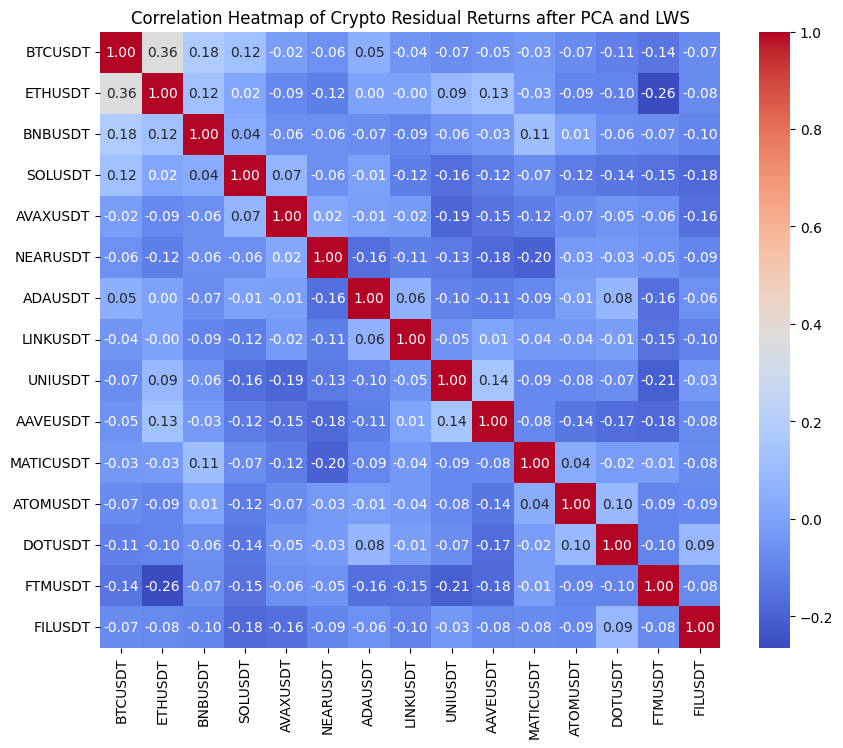

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_after_lws, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Crypto Residual Returns after PCA and LWS")
plt.show()

In [21]:
distance_matrix = np.sqrt(2 * (1 - np.abs(corr_matrix_after_lws)))
distance_matrix

,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,AVAXUSDT,NEARUSDT,ADAUSDT,LINKUSDT,UNIUSDT,AAVEUSDT,MATICUSDT,ATOMUSDT,DOTUSDT,FTMUSDT,FILUSDT
BTCUSDT,2.107342e-08,1.133092,1.283695,1.324415,1.402082,1.372934,1.376300,1.382409,1.362877,1.378956e+00,1.391207e+00,1.362381,1.334241e+00,1.309087,1.361374
ETHUSDT,1.133092e+00,0.000000,1.324954,1.403108,1.352546,1.330373,1.413579,1.412900,1.351225,1.320898e+00,1.396246e+00,1.347164,1.343793e+00,1.213056,1.358442
BNBUSDT,1.283695e+00,1.324954,NaN,1.388290,1.369758,1.368546,1.365678,1.347534,1.373831,1.393321e+00,1.331898e+00,1.407152,1.368980e+00,1.363995,1.344983
SOLUSDT,1.324415e+00,1.403108,1.388290,0.000000,1.360895,1.369331,1.409043,1.330156,1.292896,1.325124e+00,1.364106e+00,1.325405,1.312992e+00,1.302467,1.280455
AVAXUSDT,1.402082e+00,1.352546,1.369758,1.360895,0.000000,1.399778,1.406145,1.397256,1.274993,1.307002e+00,1.326810e+00,1.360830,1.381587e+00,1.368350,1.297471
NEARUSDT,1.372934e+00,1.330373,1.368546,1.369331,1.399778,NaN,1.293591,1.331563,1.321837,1.282339e+00,1.264252e+00,1.391308,1.395242e+00,1.377030,1.345431
ADAUSDT,1.376300e+00,1.413579,1.365678,1.409043,1.406145,1.293591,0.000000,1.373151,1.338494,1.331851e+00,1.348292e+00,1.405488,1.354808e+00,1.297291,1.372759
LINKUSDT,1.382409e+00,1.412900,1.347534,1.330156,1.397256,1.331563,1.373151,0.000000,1.379856,1.408876e+00,1.388178e+00,1.388290,1.404365e+00,1.300377,1.340153
UNIUSDT,1.362877e+00,1.351225,1.373831,1.292896,1.274993,1.321837,1.338494,1.379856,0.000000,1.308068e+00,1.352078e+00,1.353050,1.364137e+00,1.256185,1.389441
AAVEUSDT,1.378956e+00,1.320898,1.393321,1.325124,1.307002,1.282339,1.331851,1.408876,1.308068,1.490116e-08,1.354106e+00,1.312707,1.289059e+00,1.283926,1.358447


In [22]:
mlflow.log_param("distance_func", "np.sqrt(2 * (1 - np.abs(corr_matrix_after_lws)))")

'np.sqrt(2 * (1 - np.abs(corr_matrix_after_lws)))'

Top-k neighbors

In [23]:
def get_top_k_neighbors(distance_matrix, k=3):

    neighbors = {}

    for asset in distance_matrix.index:

        # sort distances for this asset
        distances = distance_matrix.loc[asset].sort_values()

        # remove self-distance
        distances = distances.drop(asset)

        # take k nearest
        neighbors[asset] = list(distances.index[:k])

    return neighbors

k=3
top_k = get_top_k_neighbors(distance_matrix, k)

for asset, neigh in top_k.items():
    print(asset, "→", neigh)

BTCUSDT → ['ETHUSDT', 'BNBUSDT', 'FTMUSDT']
ETHUSDT → ['BTCUSDT', 'FTMUSDT', 'AAVEUSDT']
BNBUSDT → ['BTCUSDT', 'ETHUSDT', 'MATICUSDT']
SOLUSDT → ['FILUSDT', 'UNIUSDT', 'FTMUSDT']
AVAXUSDT → ['UNIUSDT', 'FILUSDT', 'AAVEUSDT']
NEARUSDT → ['MATICUSDT', 'AAVEUSDT', 'ADAUSDT']
ADAUSDT → ['NEARUSDT', 'FTMUSDT', 'AAVEUSDT']
LINKUSDT → ['FTMUSDT', 'SOLUSDT', 'NEARUSDT']
UNIUSDT → ['FTMUSDT', 'AVAXUSDT', 'SOLUSDT']
AAVEUSDT → ['NEARUSDT', 'FTMUSDT', 'DOTUSDT']
MATICUSDT → ['NEARUSDT', 'AVAXUSDT', 'BNBUSDT']
ATOMUSDT → ['AAVEUSDT', 'SOLUSDT', 'DOTUSDT']
DOTUSDT → ['AAVEUSDT', 'SOLUSDT', 'BTCUSDT']
FTMUSDT → ['ETHUSDT', 'UNIUSDT', 'AAVEUSDT']
FILUSDT → ['SOLUSDT', 'AVAXUSDT', 'LINKUSDT']


In [24]:
mlflow.log_param("top_k_neighbors", k)

3

In [25]:
import networkx as nx

def build_topk_graph(distance_matrix, k=3):

    G = nx.Graph()

    assets = distance_matrix.index

    # add nodes
    G.add_nodes_from(assets)

    top_k = get_top_k_neighbors(distance_matrix, k)

    for asset, neighbors in top_k.items():

        for neigh in neighbors:

            weight = distance_matrix.loc[asset, neigh]

            G.add_edge(asset, neigh, weight=weight)

    return G

In [26]:
G = build_topk_graph(distance_matrix, k=3)
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 15
Edges: 31


In [27]:
mlflow.log_metric("num_graph_nodes", G.number_of_nodes())
mlflow.log_metric("num_graph_edges", G.number_of_edges())

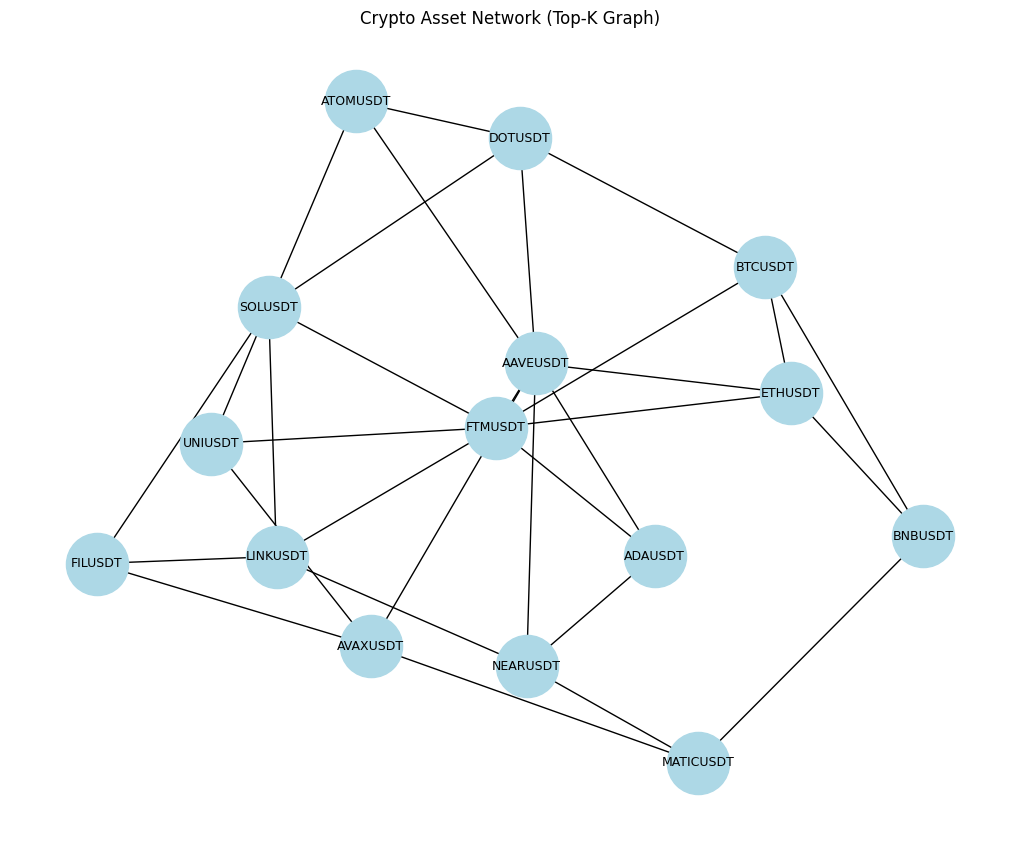

In [28]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color="lightblue",
    font_size=9
)

plt.title("Crypto Asset Network (Top-K Graph)")
plt.show()

Clustering

In [29]:
import igraph as ig

def nx_to_igraph(G):

    nodes = list(G.nodes())
    node_index = {node: i for i, node in enumerate(nodes)}

    edges = []
    weights = []

    for u, v, data in G.edges(data=True):

        edges.append((node_index[u], node_index[v]))
        weights.append(data["weight"])

    g = ig.Graph()

    g.add_vertices(len(nodes))
    g.add_edges(edges)

    g.es["weight"] = weights
    g.vs["name"] = nodes

    return g

g = nx_to_igraph(G)

In [30]:
import leidenalg as la

def run_leiden(g):

    partition = la.find_partition(
        g,
        la.ModularityVertexPartition,
        weights="weight"
    )

    return partition
partition = run_leiden(g)

In [31]:
def extract_clusters(partition, g):

    clusters = []

    for community in partition:

        cluster_assets = [g.vs[i]["name"] for i in community]

        clusters.append(cluster_assets)

    return clusters

clusters = extract_clusters(partition, g)

for i, cluster in enumerate(clusters):
    print(f"Cluster {i+1}: {cluster}")

Cluster 1: ['SOLUSDT', 'AVAXUSDT', 'LINKUSDT', 'UNIUSDT', 'FTMUSDT', 'FILUSDT']
Cluster 2: ['NEARUSDT', 'ADAUSDT', 'AAVEUSDT', 'ATOMUSDT', 'DOTUSDT']
Cluster 3: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'MATICUSDT']


In [32]:
mlflow.log_param("cluster_algorithm", "Leiden")

mlflow.log_metric("num_nodes", G.number_of_nodes())
mlflow.log_metric("num_edges", G.number_of_edges())
mlflow.log_metric("num_clusters", len(clusters))

mlflow.log_dict(
    {f"cluster_{i}": cluster for i, cluster in enumerate(clusters)},
    "clusters.json"
)

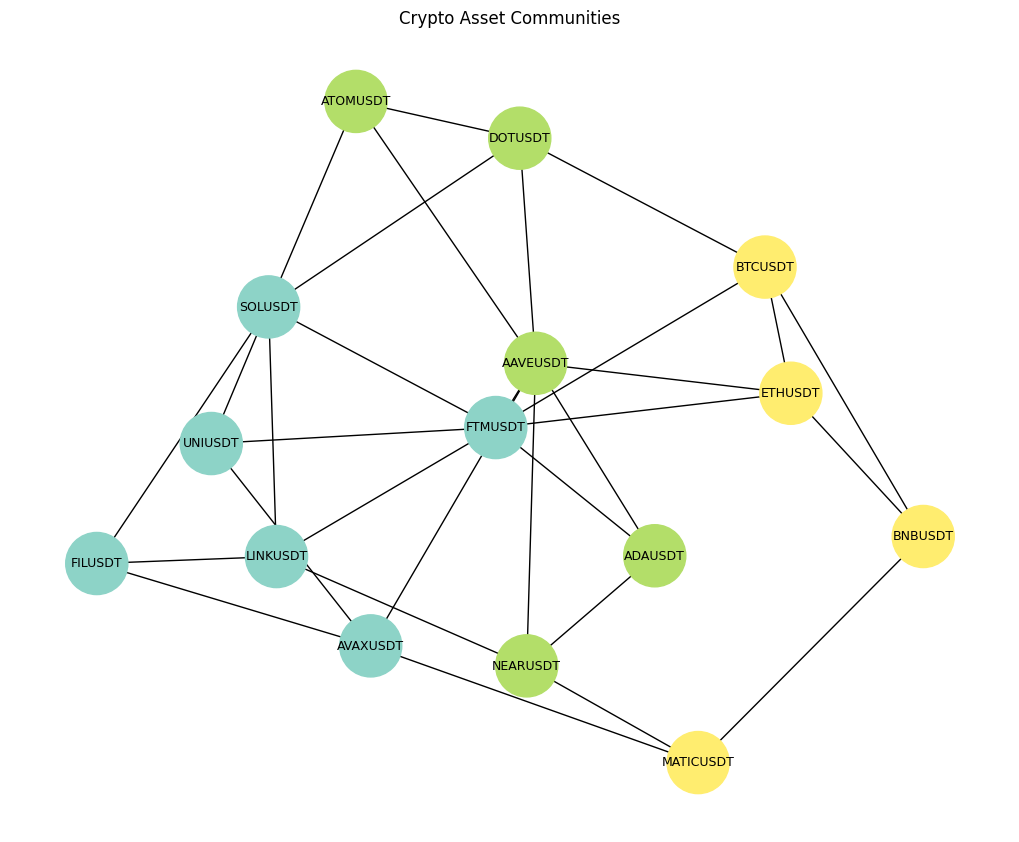

In [33]:
import matplotlib.pyplot as plt

def plot_clusters(G, clusters):

    pos = nx.spring_layout(G, seed=42)

    colors = {}

    for i, cluster in enumerate(clusters):
        for node in cluster:
            colors[node] = i

    node_colors = [colors[node] for node in G.nodes()]

    plt.figure(figsize=(10,8))

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=node_colors,
        cmap=plt.cm.Set3,
        node_size=2000,
        font_size=9
    )

    plt.title("Crypto Asset Communities")
    mlflow.log_figure(plt.gcf(), "cluster_graph.png")
    plt.show()

plot_clusters(G, clusters)

Basket generation and co-integration

In [34]:
from itertools import combinations


def generate_baskets_from_clusters(clusters, min_size=3, max_size=4):

    baskets = []

    for cluster in clusters:

        for size in range(min_size, max_size + 1):

            combos = list(combinations(cluster, size))

            for combo in combos:

                baskets.append({
                    "assets": list(combo)
                })

    return baskets

baskets = generate_baskets_from_clusters(clusters)
print("Total baskets:", len(baskets))

Total baskets: 55


In [35]:
mlflow.log_metric("candidate_baskets", len(baskets))

mlflow.log_param("basket_min_size", 3)
mlflow.log_param("basket_max_size", 4)

4

In [36]:
from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import numpy as np


def find_cointegrated_baskets(prices, symbols, min_size=2, max_size=4):
    baskets = []
    for size in range(min_size, max_size + 1):
        for combo in combinations(symbols, size):
            subset = prices[list(combo)].dropna()
            if len(subset) < 200:
                continue
            log_prices = np.log(subset)
            log_prices = log_prices.replace([np.inf, -np.inf], np.nan).dropna()

            if len(log_prices) < 200:
                continue
            try:
                result = coint_johansen(log_prices, det_order=0, k_ar_diff=1)

            except np.linalg.LinAlgError:
                continue

            trace_stats = result.lr1
            crit_vals = result.cvt[:, 1]  # 5% level

            rank = sum(trace_stats > crit_vals)

            if rank != 1:
                continue

            weights = result.evec[:, 0]
            weights = weights / np.sum(np.abs(weights))

            spread = log_prices.dot(weights)

            baskets.append({
                "assets": combo,
                "weights": weights,
                "trace": trace_stats[0],
                "spread": spread
            })

    return baskets

In [37]:
all_baskets = []

for cluster in clusters:

    baskets = find_cointegrated_baskets(prices_train, cluster)

    all_baskets.extend(baskets)

print("Total cointegrated baskets:", len(all_baskets))

Total cointegrated baskets: 19


In [38]:
mlflow.log_metric("cointegrated_baskets", len(all_baskets))

In [39]:
def compute_spread(prices, assets, weights):
    """
    Computes the spread for a cointegrated basket of assets.

    Parameters
    ----------
    prices : pandas.DataFrame
        Historical price data where columns correspond to asset symbols.

    assets : list[str]
        List of asset symbols forming the cointegrated basket.

    weights : numpy.ndarray
        Cointegration vector (weights) corresponding to the assets.

    Returns
    -------
    pandas.Series
        The spread, calculated as the weighted combination of the log prices of the basket assets.
    """
    log_prices = np.log(prices[list(assets)])
    spread = log_prices @ weights
    return spread

In [40]:
spreads = []

for basket in all_baskets:

    assets = basket["assets"]
    weights = basket["weights"]

    spread_train = compute_spread(prices_train, assets, weights)
    spread_test  = compute_spread(prices_test, assets, weights)

    spread = pd.concat([spread_train, spread_test])

    spreads.append({
        "assets": assets,
        "weights": weights,
        "spread": spread
    })

Diagnosing and filtering baskets that are actually mean reverting.

In [41]:
import statsmodels.api as sm

def predictive_regression(spread, horizon=5, window=30):

    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()

    future_change = spread.shift(-horizon) - spread

    df = pd.DataFrame({
        "z": z,
        "future": future_change
    }).dropna()

    X = sm.add_constant(df["z"])

    model = sm.OLS(df["future"], X).fit()

    beta = model.params["z"]
    tstat = model.tvalues["z"]

    return beta, tstat

In [42]:
def half_life(spread):
    """
    Estimate the half-life of mean reversion for a spread. It measures how quickly spread reverts back to it's long-term mean after a deviation.

    Parameters
    ----------
    spread : pandas.Series
        Time series representing the spread constructed from a basket of assets.

    Returns
    -------
    float
        Estimated half-life of mean reversion (in time steps). Lower values imply 
        faster reversion to the mean.
    """
    lag = spread.shift(1).dropna()
    delta = spread.diff().dropna()

    lag = lag.loc[delta.index]

    beta = np.polyfit(lag, delta, 1)[0]

    if beta >= 0:
        return np.inf
    
    hl = -np.log(2) / beta

    return abs(hl)



In [43]:
def variance_ratio(spread, k=5):

    r1 = spread.diff().dropna()
    rk = spread.diff(k).dropna()

    vr = rk.var() / (k * r1.var())

    return vr

In [44]:
def signal_sharpe(spread, horizon=5, window=30):

    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()

    future_change = spread.shift(-horizon) - spread

    df = pd.DataFrame({
        "z": z,
        "future": future_change
    }).dropna()

    signal = -np.sign(df["z"])

    pnl = signal * df["future"]

    sharpe = pnl.mean() / pnl.std() * np.sqrt(365 / horizon)

    return sharpe

In [45]:
results = []
horizon=5
window=30
var_ratio_k=5

for s in spreads:

    spread = s["spread"].loc[:TRAIN_END]

    beta, tstat = predictive_regression(spread,horizon,window)
    hl = half_life(spread)
    vr = variance_ratio(spread,var_ratio_k)
    sharpe = signal_sharpe(spread,horizon,window)

    results.append({
        "assets": s["assets"],
        "beta": beta,
        "tstat": tstat,
        "half_life": hl,
        "variance_ratio": vr,
        "sharpe": sharpe
    })

results_df = pd.DataFrame(results)
results_df

,assets,beta,tstat,half_life,variance_ratio,sharpe
0,"(SOLUSDT, LINKUSDT)",-0.002156,-1.780477,34.937208,0.933409,0.002603
1,"(AVAXUSDT, LINKUSDT)",0.006315,2.635615,111.867463,1.044753,-0.686804
2,"(AVAXUSDT, FTMUSDT)",-0.000966,-0.975069,56.460188,0.980932,0.032174
3,"(LINKUSDT, UNIUSDT)",0.000522,0.367480,36.148177,0.884146,-0.421565
4,"(SOLUSDT, AVAXUSDT, FILUSDT)",-0.003491,-4.575461,21.291583,0.938691,0.837704
5,"(SOLUSDT, LINKUSDT, UNIUSDT)",-0.001679,-1.279838,30.657331,0.936137,0.019635
6,"(AVAXUSDT, LINKUSDT, UNIUSDT)",-0.001450,-1.111623,30.290930,0.883690,-0.174532
7,"(AVAXUSDT, LINKUSDT, FTMUSDT)",0.003230,2.391415,61.328401,1.010411,-0.556997
8,"(AVAXUSDT, LINKUSDT, FILUSDT)",-0.002665,-3.094875,21.886016,1.021684,0.363304
9,"(SOLUSDT, AVAXUSDT, LINKUSDT, FILUSDT)",-0.003220,-4.228039,16.668485,0.982129,1.091162


In [46]:
mlflow.log_metric("horizon", horizon)
mlflow.log_metric("rolling_window_size", window)
mlflow.log_metric("variance_ratio_kvalue", var_ratio_k)

mlflow.log_table(
    data=results_df,
    artifact_file="candidate_baskets_diagnostics.json"
)
mlflow.log_metric("candidate_baskets", len(results_df))

Classify baskets to momentum or reversal.

In [47]:
def classify_basket_type(results_df):
    
    df = results_df.copy()
    
    df["type"] = np.where(df["beta"] < 0, "reversion", "momentum")
    
    return df

In [48]:
def compute_basket_scores(results_df):

    df = results_df.copy()

    # classify baskets
    df = classify_basket_type(df)

    # adjust variance ratio depending on strategy
    df["vr_adj"] = np.where(
        df["type"] == "reversion",
        1 - df["variance_ratio"],
        df["variance_ratio"]
    )

    # avoid divide-by-zero
    df["hl_inv"] = 1 / df["half_life"].replace(0, np.nan)

    # composite score
    df["score"] = (
        0.4 * np.abs(df["tstat"]) +
        0.3 * df["sharpe"] +
        0.2 * df["hl_inv"] +
        0.1 * df["vr_adj"]
    )

    return df

In [49]:
scored_df = compute_basket_scores(results_df)

scored_df.sort_values("score", ascending=False)

,assets,beta,tstat,half_life,variance_ratio,sharpe,type,vr_adj,hl_inv,score
10,"(SOLUSDT, AVAXUSDT, UNIUSDT, FILUSDT)",-0.003494,-4.578963,21.294196,0.938706,0.858977,reversion,0.061294,0.046961,2.104800
4,"(SOLUSDT, AVAXUSDT, FILUSDT)",-0.003491,-4.575461,21.291583,0.938691,0.837704,reversion,0.061309,0.046967,2.097020
9,"(SOLUSDT, AVAXUSDT, LINKUSDT, FILUSDT)",-0.003220,-4.228039,16.668485,0.982129,1.091162,reversion,0.017871,0.059993,2.032350
15,"(BTCUSDT, BNBUSDT)",0.003294,3.921813,54.559965,1.017861,-0.316522,momentum,1.017861,0.018328,1.579220
18,"(BTCUSDT, ETHUSDT, BNBUSDT)",0.003072,3.897573,52.408757,1.012581,-0.303713,momentum,1.012581,0.019081,1.572989
12,"(AVAXUSDT, LINKUSDT, UNIUSDT, FILUSDT)",-0.002578,-3.020809,20.939832,1.034051,0.502855,reversion,-0.034051,0.047756,1.365326
8,"(AVAXUSDT, LINKUSDT, FILUSDT)",-0.002665,-3.094875,21.886016,1.021684,0.363304,reversion,-0.021684,0.045691,1.353911
1,"(AVAXUSDT, LINKUSDT)",0.006315,2.635615,111.867463,1.044753,-0.686804,momentum,1.044753,0.008939,0.954468
7,"(AVAXUSDT, LINKUSDT, FTMUSDT)",0.003230,2.391415,61.328401,1.010411,-0.556997,momentum,1.010411,0.016306,0.893769
11,"(AVAXUSDT, LINKUSDT, UNIUSDT, FTMUSDT)",-0.002375,-2.028508,28.677240,0.868434,0.141578,reversion,0.131566,0.034871,0.874007


In [50]:
def select_top_baskets(scored_df, top_frac=0.3):

    df = scored_df.sort_values("score", ascending=False)

    n = int(len(df) * top_frac)

    top_df = df.iloc[:n].copy()

    return top_df

In [51]:
top_frac=0.3
top_baskets_df = select_top_baskets(scored_df, top_frac)

print(len(top_baskets_df))
top_baskets_df[["assets","score","type"]]

5


,assets,score,type
10,"(SOLUSDT, AVAXUSDT, UNIUSDT, FILUSDT)",2.104800,reversion
4,"(SOLUSDT, AVAXUSDT, FILUSDT)",2.097020,reversion
9,"(SOLUSDT, AVAXUSDT, LINKUSDT, FILUSDT)",2.032350,reversion
15,"(BTCUSDT, BNBUSDT)",1.579220,momentum
18,"(BTCUSDT, ETHUSDT, BNBUSDT)",1.572989,momentum


In [52]:
mlflow.log_metric("top_fraction_selected", top_frac)
mlflow.log_table(
    data=top_baskets_df,
    artifact_file="selected_baskets.json"
)
mlflow.log_metric("selected_baskets", len(top_baskets_df))

In [53]:
def get_selected_spreads(top_baskets_df, spreads):

    selected = []

    asset_sets = set(top_baskets_df["assets"].apply(tuple))

    for s in spreads:

        if tuple(s["assets"]) in asset_sets:
            selected.append(s)

    return selected

In [54]:
selected_spreads = get_selected_spreads(top_baskets_df, spreads)

len(selected_spreads)

5

In [55]:
def remove_correlated_spreads(spreads, threshold=0.6):

    spreads = spreads.copy()

    keep = []
    spreads_df = pd.DataFrame()

    for s in spreads:

        spreads_df[str(s["assets"])] = s["spread"].loc[:TRAIN_END]

    corr = spreads_df.corr()

    used = set()

    for col in corr.columns:

        if col in used:
            continue

        keep.append(col)

        high_corr = corr.index[corr[col].abs() > threshold]

        used.update(high_corr)

    selected = []

    for s in spreads:
        if str(s["assets"]) in keep:
            selected.append(s)

    return selected

In [56]:
threshold=0.6
final_spreads = remove_correlated_spreads(selected_spreads,threshold)
final_spreads

[{'assets': ('SOLUSDT', 'AVAXUSDT', 'FILUSDT'),
  'weights': array([ 0.17529232, -0.46883111,  0.35587657]),
  'spread': open_time
  2021-01-01         NaN
  2021-01-02         NaN
  2021-01-03         NaN
  2021-01-04         NaN
  2021-01-05         NaN
                  ...   
  2026-02-25   -0.239578
  2026-02-26   -0.253276
  2026-02-27   -0.263580
  2026-02-28   -0.257853
  2026-03-01   -0.259994
  Freq: D, Length: 1886, dtype: float64},
 {'assets': ('BTCUSDT', 'BNBUSDT'),
  'weights': array([ 0.41510378, -0.58489622]),
  'spread': open_time
  2021-01-01    2.147057
  2021-01-02    2.177174
  2021-01-03    2.145368
  2021-01-04    2.132830
  2021-01-05    2.147225
                  ...   
  2026-02-25    0.852856
  2026-02-26    0.849505
  2026-02-27    0.850619
  2026-02-28    0.854426
  2026-03-01    0.843431
  Freq: D, Length: 1886, dtype: float64}]

In [57]:
mlflow.log_metric("corr_threshold",threshold)
mlflow.log_metric("final_spreads", len(final_spreads))

fs_data = [
    {
        "assets": list(d["assets"]),
        "weights": d["weights"].tolist()
    }
    for d in final_spreads
]
fs_df = pd.DataFrame(fs_data)
mlflow.log_table(
    fs_df,
    artifact_file="final_spreads.json"
)


Signal Construction

In [58]:
def strat_zscore_reversion(spread, entry=1.5, window=30):

    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()

    pos = pd.Series(0, index=spread.index)

    pos[z > entry] = -1
    pos[z < -entry] = 1

    pos = pos.ffill().fillna(0)

    return pos

In [59]:
def strat_bollinger_reversion(spread, window=30, k=2):

    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()

    upper = mean + k * std
    lower = mean - k * std

    pos = pd.Series(0, index=spread.index)

    pos[spread > upper] = -1
    pos[spread < lower] = 1

    pos = pos.ffill().fillna(0)

    return pos

In [60]:
def strat_ou_reversion(spread, window=30):

    mean = spread.rolling(window).mean()

    pos = -np.sign(spread - mean)

    pos = pd.Series(pos, index=spread.index)

    return pos

In [61]:
def strat_spread_momentum(spread, lookback=20):

    momentum = spread - spread.shift(lookback)

    pos = np.sign(momentum)

    pos = pd.Series(pos, index=spread.index)

    return pos

In [62]:
def strat_ma_crossover(spread, short=10, long=40):

    ma_short = spread.rolling(short).mean()
    ma_long = spread.rolling(long).mean()

    pos = np.sign(ma_short - ma_long)

    pos = pd.Series(pos, index=spread.index)

    return pos

In [63]:
def strat_zscore_momentum(spread, window=30, threshold=1):

    z = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()

    pos = pd.Series(0, index=spread.index)

    pos[z > threshold] = 1
    pos[z < -threshold] = -1

    pos = pos.ffill().fillna(0)

    return pos

In [64]:
reversion_strategies = {
    "zscore_rev": strat_zscore_reversion,
    "bollinger_rev": strat_bollinger_reversion,
    "ou_rev": strat_ou_reversion
}

momentum_strategies = {
    "momentum": strat_spread_momentum,
    "ma_cross": strat_ma_crossover,
    "zscore_mom": strat_zscore_momentum
}

In [65]:
def unconstrained_backtest(prices, assets, weights, pos):

    log_prices = np.log(prices[list(assets)])

    log_returns = log_prices.diff().fillna(0)

    pos = pos.reindex(log_returns.index).fillna(0)

    basket_ret = (log_returns * weights).sum(axis=1)

    pnl = pos.shift(1).fillna(0) * basket_ret

    return pnl

In [66]:
def walk_forward_validation(prices, spread, assets, weights, strategy_func,
                             train_size=365, test_size=30):
    pnl_all = []
    start = 0
    n = len(spread)

    while start + train_size + test_size <= n:
        train_idx = spread.index[start:start + train_size]
        test_idx  = spread.index[start + train_size:start + train_size + test_size]

        spread_train = spread.loc[train_idx]
        spread_full  = spread.iloc[start:start + train_size + test_size]

        pos_test = pd.Series(index=test_idx, dtype=float)

        for t in test_idx:
            # Build history = train + test observations strictly before t
            spread_history = spread_full.loc[:t].iloc[:-1]  # exclude t itself

            # spread_history already starts from train_idx[0], no extra concat needed
            pos_series = strategy_func(spread_history)
            pos_test.loc[t] = pos_series.iloc[-1]

        pnl_test = unconstrained_backtest(prices.loc[test_idx], assets, weights, pos_test)
        pnl_all.append(pnl_test)

        start += test_size

    return pd.concat(pnl_all)

In [67]:
def sharpe_ratio(pnl):
    
    pnl = pnl.dropna()

    if pnl.std() == 0:
        return -np.inf

    return pnl.mean() / pnl.std() * np.sqrt(365)

In [68]:
def select_best_strategy_walkforward(
        prices,
        spread,
        assets,
        weights,
        strategies,
        train_size=365,
        test_size=30):

    best_strategy = None
    best_sharpe = -np.inf
    best_pnl = None

    strategy_results = []

    for name, strat_func in strategies.items():

        pnl = walk_forward_validation(
            prices,
            spread,
            assets,
            weights,
            strat_func,
            train_size=train_size,
            test_size=test_size
        )

        sr = sharpe_ratio(pnl)

        strategy_results.append({
            "strategy": name,
            "sharpe": sr
        })

        if sr > best_sharpe:
            best_sharpe = sr
            best_strategy = name
            best_pnl = pnl

    results_df = pd.DataFrame(strategy_results)

    return best_strategy, best_pnl, results_df

In [69]:
basket_pnls = {}
basket_strategy = {}
basket_strategy_results = {}
train_size = 365
test_size=30

for s in final_spreads:

    assets = s["assets"]
    weights = s["weights"]
    spread = s["spread"]

    beta = results_df.loc[
        results_df["assets"] == tuple(assets),
        "beta"
    ].values[0]

    basket_type = "reversion" if beta < 0 else "momentum"

    strategies = (
        reversion_strategies
        if basket_type == "reversion"
        else momentum_strategies
    )

    best_strat, pnl, strat_results = select_best_strategy_walkforward(
        prices,
        spread.loc[:TRAIN_END],
        assets,
        weights,
        strategies,
        train_size,
        test_size
    )

    basket_pnls[str(assets)] = pnl
    basket_strategy[str(assets)] = best_strat
    basket_strategy_results[str(assets)] = strat_results

In [70]:
mlflow.log_param("walkforward_train_days", 365)
mlflow.log_param("walkforward_test_days", 30)

30

In [71]:
basket_returns = pd.DataFrame(basket_pnls)
basket_returns

,"('SOLUSDT', 'AVAXUSDT', 'FILUSDT')","('BTCUSDT', 'BNBUSDT')"
open_time,,
2022-01-01,0.000000,0.000000
2022-01-02,0.000000,-0.000000
2022-01-03,0.000000,0.000000
2022-01-04,0.000000,0.000000
2022-01-05,-0.000000,0.000000
...,...,...
2025-06-09,0.000863,0.005448
2025-06-10,0.011056,-0.000000
2025-06-11,0.000000,-0.002095


In [72]:
mlflow.log_table(
    basket_returns,
    artifact_file="basket_returns.json"
)

In [73]:
for k,v in basket_strategy.items():
    print(k, "→", v)

('SOLUSDT', 'AVAXUSDT', 'FILUSDT') → bollinger_rev
('BTCUSDT', 'BNBUSDT') → zscore_mom


In [74]:
mlflow.log_param("basket_strategy", basket_strategy)

{"('SOLUSDT', 'AVAXUSDT', 'FILUSDT')": 'bollinger_rev',
 "('BTCUSDT', 'BNBUSDT')": 'zscore_mom'}

In [75]:
rows=[]
for basket, df in basket_strategy_results.items():
    temp = df.copy()
    temp["basket"] = basket
    rows.append(temp)

strategy_results_df = pd.concat(rows, ignore_index=True)

mlflow.log_table(
    strategy_results_df,
    artifact_file="strategy_results.json"
)

Out of Sample Testing

In [76]:
# -----------------------------
# FINAL OUT-OF-SAMPLE BACKTEST
# -----------------------------

final_pnls = {}

for s in final_spreads:

    assets = s["assets"]
    weights = s["weights"]
    spread = s["spread"]

    strat_name = basket_strategy[str(assets)]

    # pick correct strategy function
    if strat_name in reversion_strategies:
        strategy_func = reversion_strategies[strat_name]
    else:
        strategy_func = momentum_strategies[strat_name]

    # build signal using entire spread history
    pos = strategy_func(spread)

    # keep only test period signals
    pos_test = pos.loc[prices_test.index]

    # compute pnl on test data
    pnl = unconstrained_backtest(
        prices_test,
        assets,
        weights,
        pos_test
    )

    final_pnls[str(assets)] = pnl

basket_returns_test = pd.DataFrame(final_pnls)

basket_returns_test

,"('SOLUSDT', 'AVAXUSDT', 'FILUSDT')","('BTCUSDT', 'BNBUSDT')"
open_time,,
2025-07-01,0.0,0.0
2025-07-02,-0.0,0.0
2025-07-03,0.0,-0.0
2025-07-04,-0.0,0.0
2025-07-05,-0.0,-0.0
...,...,...
2026-02-25,0.0,-0.0
2026-02-26,-0.0,-0.0
2026-02-27,-0.0,0.0


In [77]:
mlflow.log_table(
    basket_returns_test,
    artifact_file="oos_test_returns.json"
)

In [78]:
def equal_weight_portfolio(basket_returns):

    weights = np.ones(basket_returns.shape[1]) / basket_returns.shape[1]

    portfolio = basket_returns.dot(weights)

    return portfolio

In [79]:
def volatility_weighted_portfolio(basket_returns, window=60):

    vol = basket_returns.rolling(window).std()

    inv_vol = 1 / vol

    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)

    weights = weights.fillna(method="bfill").fillna(method="ffill")

    portfolio = (basket_returns * weights).sum(axis=1)

    return portfolio, weights

In [80]:
def sharpe_weighted_portfolio(basket_returns, window=90):

    mean = basket_returns.rolling(window).mean()
    vol = basket_returns.rolling(window).std()

    sharpe = mean / vol

    sharpe = sharpe.clip(lower=0)

    weights = sharpe.div(sharpe.sum(axis=1), axis=0)

    weights = weights.fillna(method="bfill").fillna(method="ffill")

    portfolio = (basket_returns * weights).sum(axis=1)

    return portfolio, weights

In [81]:
portfolio_equal = equal_weight_portfolio(basket_returns_test)

portfolio_vol, vol_weights = volatility_weighted_portfolio(basket_returns_test)

portfolio_sharpe, sharpe_weights = sharpe_weighted_portfolio(basket_returns_test)

In [82]:
def performance_metrics(returns):

    ann_return = returns.mean() * 365
    ann_vol = returns.std() * np.sqrt(365)

    sharpe = ann_return / ann_vol

    cum = (1 + returns).cumprod()

    dd = cum / cum.cummax() - 1

    max_dd = dd.min()

    return {
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    }

In [83]:
perf_df = pd.DataFrame({
    "Equal Weight": performance_metrics(portfolio_equal),
    "Vol Weight": performance_metrics(portfolio_vol),
    "Sharpe Weight": performance_metrics(portfolio_sharpe)
}).T
perf_df

,Annual Return,Annual Vol,Sharpe,Max Drawdown
Equal Weight,0.224078,0.182127,1.230340,-0.122034
Vol Weight,0.169497,0.165207,1.025970,-0.114712
Sharpe Weight,0.413234,0.188119,2.196662,-0.085808


In [84]:
mlflow.log_table(
    perf_df,
    artifact_file="uncon_metrics.json"
)

In [85]:
weights = pd.DataFrame(
    vol_weights,
    index=basket_returns_test.index,
    columns=basket_returns_test.columns
)
weights

,"('SOLUSDT', 'AVAXUSDT', 'FILUSDT')","('BTCUSDT', 'BNBUSDT')"
open_time,,
2025-07-01,0.677632,0.322368
2025-07-02,0.677632,0.322368
2025-07-03,0.677632,0.322368
2025-07-04,0.677632,0.322368
2025-07-05,0.677632,0.322368
...,...,...
2026-02-25,0.565759,0.434241
2026-02-26,0.560655,0.439345
2026-02-27,0.560655,0.439345


In [86]:
turnover = (
    weights.fillna(0)
    - weights.shift().fillna(0)
).abs().sum(axis=1)
turnover

open_time
2025-07-01    1.000000
2025-07-02    0.000000
2025-07-03    0.000000
2025-07-04    0.000000
2025-07-05    0.000000
                ...   
2026-02-25    0.002862
2026-02-26    0.010209
2026-02-27    0.000000
2026-02-28    0.000000
2026-03-01    0.000000
Freq: D, Length: 244, dtype: float64

In [87]:
gross_ret = (weights.shift() * basket_returns_test).sum(axis=1)
gross_ret

open_time
2025-07-01    0.0
2025-07-02    0.0
2025-07-03    0.0
2025-07-04    0.0
2025-07-05    0.0
             ... 
2026-02-25    0.0
2026-02-26    0.0
2026-02-27    0.0
2026-02-28    0.0
2026-03-01    0.0
Freq: D, Length: 244, dtype: float64

In [88]:
tcost = 20 * 1e-4
net_ret = gross_ret - turnover * tcost
net_ret

open_time
2025-07-01   -0.002000
2025-07-02    0.000000
2025-07-03    0.000000
2025-07-04    0.000000
2025-07-05    0.000000
                ...   
2026-02-25   -0.000006
2026-02-26   -0.000020
2026-02-27    0.000000
2026-02-28    0.000000
2026-03-01    0.000000
Freq: D, Length: 244, dtype: float64

In [89]:
def perf_stats(r):

    ann_ret = r.mean() * 365
    ann_vol = r.std() * np.sqrt(365)

    sharpe = ann_ret / ann_vol

    cum = (1 + r).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()

    return {
        "Annual Return": ann_ret,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd
    }

print("Gross:", perf_stats(gross_ret))
print("Net:", perf_stats(net_ret))

Gross: {'Annual Return': np.float64(0.1999381210944553), 'Annual Vol': np.float64(0.18709036004280102), 'Sharpe': np.float64(1.0686714219199487), 'Max Drawdown': np.float64(-0.12518755092679268)}
Net: {'Annual Return': np.float64(0.18188912067391796), 'Annual Vol': np.float64(0.18684703228662078), 'Sharpe': np.float64(0.9734653981279325), 'Max Drawdown': np.float64(-0.12982291177064453)}


In [90]:
con_df = pd.DataFrame({
    "Gross": perf_stats(gross_ret),
    "Net": perf_stats(net_ret)
}).T
con_df

,Annual Return,Annual Vol,Sharpe,Max Drawdown
Gross,0.199938,0.187090,1.068671,-0.125188
Net,0.181889,0.186847,0.973465,-0.129823


In [91]:
mlflow.log_table(
    con_df,
    artifact_file="con_metrics.json"
)

In [92]:
btc_ret = prices_test["BTCUSDT"].pct_change()

# align series
df = pd.concat([net_ret, btc_ret], axis=1)

df.columns = ["strategy", "btc"]

df = df.replace([np.inf, -np.inf], np.nan).dropna()

X = sm.add_constant(df["btc"])

model = sm.OLS(df["strategy"], X).fit()

alpha = model.params["const"] * 365
beta = model.params["btc"]

print("Alpha:", alpha)
print("Beta:", beta)

Alpha: 0.1904123341776477
Beta: 0.007787318267734048


In [93]:
mlflow.log_metric("alpha", alpha)
mlflow.log_metric("beta", beta)

In [94]:
annual_turnover = turnover.mean() * 365
print("Annual Turnover:", annual_turnover)

Annual Turnover: 9.024500210268725


In [95]:
holding_period = 1 / turnover.mean()
print("Average holding period (days):", holding_period)

Average holding period (days): 40.44545309940563


In [96]:
r = net_ret.copy()

import numpy as np
import pandas as pd

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(365)

r = net_ret.dropna()

real_sharpe = sharpe(r)

n_sim = 5000
random_sharpes = []

for _ in range(n_sim):

    signs = np.random.choice([-1,1], size=len(r))
    shuffled = r.values * signs

    random_sharpes.append(sharpe(pd.Series(shuffled)))

random_sharpes = np.array(random_sharpes)

p_value = np.mean(random_sharpes >= real_sharpe)

print("Strategy Sharpe:", real_sharpe)
print("Random Sharpe mean:", random_sharpes.mean())
print("Random Sharpe 95%:", np.percentile(random_sharpes,95))
print("p-value:", p_value)

Strategy Sharpe: 0.9734653981279324
Random Sharpe mean: -0.017301388303927513
Random Sharpe 95%: 1.992599393078671
p-value: 0.218


In [97]:
mlflow.log_metric("annual_turnover", annual_turnover)
mlflow.log_metric("holding_period", holding_period)
mlflow.log_metric("p_value", p_value)
mlflow.log_metric("strategy_sharpe", real_sharpe)
mlflow.log_metric("random_sharpe_mean", random_sharpes.mean())

In [98]:
mlflow.end_run()